# Personalized Query Suggestion — Modern Approaches
## NI-ADM | Czech Technical University in Prague

*Task and feedback by Daniel Bohunek ([Recombee](https://www.recombee.com/))*

This tutorial builds on the [LTR tutorial](ltr_tutorial.ipynb) where we covered classic pointwise/pairwise/listwise ranking. Now we move to **modern neural methods** applied to a real task: **personalized query suggestion**.

**Task:** Given a user's search history, predict/rank which queries they will search for next.

We will:
1. Load and explore the **AOL4PS** dataset (users, queries, clicks)
2. Build **semantic evaluation** metrics (fuzzy NDCG/MRR using embeddings)
3. Compare **baselines** (popularity, collaborative filtering, content-based)
4. Implement **modern methods**: Two-Tower model, sequential (GRU), LoRA fine-tuning
5. Discuss how these connect to the classic LTR pipeline

---

### Problem Formulation

We treat **queries as items** and **search events as interactions**:

| Concept | In our task |
|---------|-------------|
| User | Anonymized searcher |
| Item | A search query (text) |
| Interaction | User issued this query |
| Goal | Rank candidate queries for next suggestion |

This is a **next-item prediction** problem — we can use recommendation models!

## 0. Setup

In [1]:
# Install required packages (run once)
!pip install pandas scikit-learn lightgbm matplotlib seaborn torch sentence-transformers -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import warnings
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device: {device}')
print('All imports OK!')

PyTorch device: cpu
All imports OK!


## 1. Download & Load the AOL4PS Dataset

The [AOL4PS dataset](https://doi.org/10.11922/sciencedb.j00104.00093) contains:
- **data.csv**: user interactions — AnonID, QueryIndex, QueryTime, SessionNo, DataType (0=history, 1=train, 2=val, 3=test), DocIndex, CandiList, ClickPos
- **query.csv**: QueryIndex → query text
- **doc.csv**: DocIndex → URL, title

All files are **tab-separated** (TSV). QueryIndex values are **strings** (e.g. `q-0`, `q-1`, ...).

Source: [github.com/wanhuaiyu/AOL4PS](https://github.com/wanhuaiyu/AOL4PS)

In [3]:
import urllib.request
import tarfile

DATA_DIR = 'data/AOL4PS'
os.makedirs(DATA_DIR, exist_ok=True)

REPO_BASE = 'https://github.com/wanhuaiyu/AOL4PS/raw/main'
FILES = ['data.tar.gz', 'query.tar.gz', 'doc.tar.gz']

for fname in FILES:
    csv_name = fname.replace('.tar.gz', '.csv')
    csv_path = os.path.join(DATA_DIR, csv_name)
    tar_path = os.path.join(DATA_DIR, fname)
    
    if os.path.exists(csv_path):
        print(f'  {csv_name} already exists, skipping.')
        continue
    
    print(f'  Downloading {fname}...')
    urllib.request.urlretrieve(f'{REPO_BASE}/{fname}', tar_path)
    
    print(f'  Extracting {fname}...')
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=DATA_DIR)
    
    os.remove(tar_path)
    print(f'  -> {csv_name} ready.')

print('\nAll AOL4PS files ready!')

  data.csv already exists, skipping.
  query.csv already exists, skipping.
  doc.csv already exists, skipping.

All AOL4PS files ready!


In [4]:
# Load the data — IMPORTANT: files are TAB-separated, QueryIndex is string
df_data = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'), sep='\t',
                      dtype={'QueryIndex': str, 'DocIndex': str, 'CandiList': str})
df_queries = pd.read_csv(os.path.join(DATA_DIR, 'query.csv'), sep='\t',
                         dtype={'QueryIndex': str})
df_docs = pd.read_csv(os.path.join(DATA_DIR, 'doc.csv'), sep='\t',
                      dtype={'DocIndex': str})

print(f'Interactions: {len(df_data):,}')
print(f'Unique users: {df_data.AnonID.nunique():,}')
print(f'Unique queries: {df_queries.QueryIndex.nunique():,}')
print(f'Documents: {len(df_docs):,}')
print(f'\nData splits: {dict(df_data.DataType.value_counts().sort_index())}')
print(f'  0=history, 1=train, 2=validation, 3=test')
df_data.head()

Interactions: 1,339,101
Unique users: 12,907
Unique queries: 429,286
Documents: 951,940

Data splits: {0: np.int64(1012955), 1: np.int64(218559), 2: np.int64(54230), 3: np.int64(53357)}
  0=history, 1=train, 2=validation, 3=test


,AnonID,QueryIndex,QueryTime,SessionNo,DataType,DocIndex,CandiList,ClickPos
0,1035,q-0,2006-03-01 13:49:07,1,0,d-1098,d-926666\td-135426\td-506247\td-747730\td-2644...,8
1,1035,q-1,2006-03-01 16:47:51,2,0,d-1099,d-440399\td-562364\td-944748\td-46840\td-62632...,9
2,1035,q-2,2006-03-02 17:51:52,3,0,d-1100,d-104465\td-393429\td-535757\td-2930\td-264993...,5
3,1035,q-1,2006-03-03 08:41:19,4,0,d-1099,d-440399\td-562364\td-944748\td-46840\td-62632...,9
4,1035,q-3,2006-03-03 16:24:27,5,0,d-393,d-593459\td-771420\td-726109\td-2527\td-506561...,5


## 2. Explore the Data

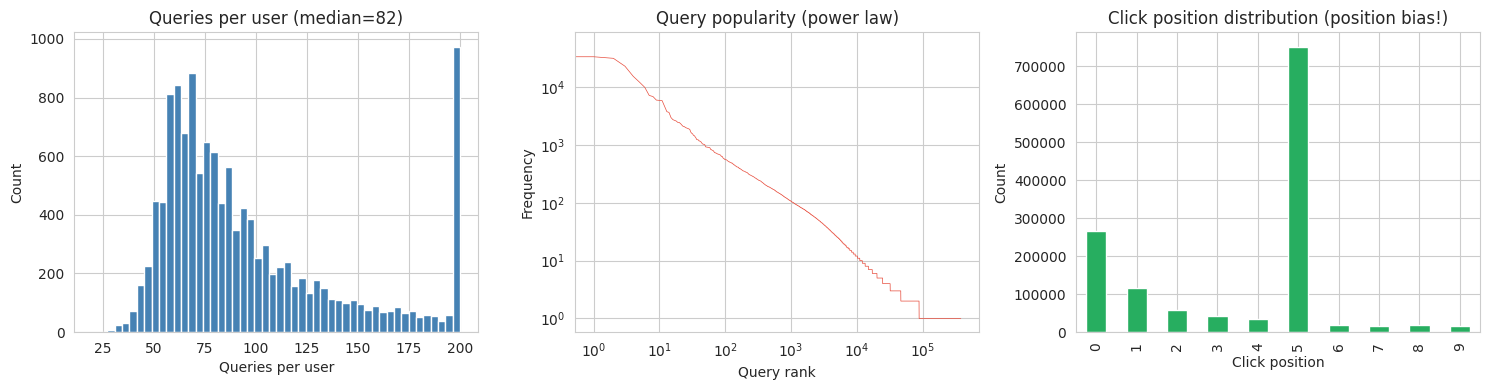

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

qpu = df_data.groupby('AnonID').size()
axes[0].hist(qpu.clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Queries per user'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Queries per user (median={qpu.median():.0f})')

qpop = df_data.groupby('QueryIndex').size().sort_values(ascending=False)
axes[1].plot(range(len(qpop)), qpop.values, color='#e74c3c', linewidth=0.5)
axes[1].set_xlabel('Query rank'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Query popularity (power law)')
axes[1].set_xscale('log'); axes[1].set_yscale('log')

df_data['ClickPos'].clip(upper=10).value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='#27ae60')
axes[2].set_xlabel('Click position'); axes[2].set_ylabel('Count')
axes[2].set_title('Click position distribution (position bias!)')

plt.tight_layout(); plt.show()

In [6]:
merged = df_data.merge(df_queries, on='QueryIndex', how='left')

print('Top 15 most popular queries:')
top_q = merged.groupby('Query').size().sort_values(ascending=False).head(15)
for i, (q, c) in enumerate(top_q.items(), 1):
    print(f'  {i:2d}. "{q}" ({c:,} searches)')

sample_user = merged[merged.DataType == 0].groupby('AnonID').size()
sample_uid = sample_user[sample_user.between(10, 30)].index[0]
user_sess = merged[merged.AnonID == sample_uid].sort_values('QueryTime').head(10)
print(f'\nSample user {sample_uid} session:')
for _, row in user_sess.iterrows():
    print(f'  [{row.QueryTime}] Session {row.SessionNo}: "{row.Query}"')

Top 15 most popular queries:
   1. "google" (51,250 searches)
   2. "yahoo" (33,357 searches)
   3. "ebay" (31,339 searches)
   4. "myspace" (22,883 searches)
   5. "yahoo.com" (15,334 searches)
   6. "myspace.com" (12,094 searches)
   7. "mapquest" (9,871 searches)
   8. "craigslist" (7,164 searches)
   9. "bank of america" (6,838 searches)
  10. "yahoo mail" (5,947 searches)
  11. "www.yahoo.com" (5,873 searches)
  12. "google.com" (5,824 searches)
  13. "bankofamerica" (4,607 searches)
  14. "www.myspace.com" (3,753 searches)
  15. "fidelity.com" (3,643 searches)

Sample user 1338 session:
  [2006-03-02 08:24:56] Session 87: "southampton county virginia"
  [2006-03-03 12:18:36] Session 88: "xnxx"
  [2006-03-03 12:54:46] Session 89: "virginia lottery"
  [2006-03-03 13:01:19] Session 89: "virginia lottery"
  [2006-03-04 10:42:42] Session 90: "thesabre"
  [2006-03-05 08:30:01] Session 91: "virginia lottery"
  [2006-03-08 10:12:47] Session 92: "ellen drames"
  [2006-03-08 10:23:40] Sess

## 3. Prepare Train/Val/Test Splits

In [7]:
merged = df_data.merge(df_queries, on='QueryIndex', how='left')
merged = merged.dropna(subset=['Query'])

df_history = merged[merged.DataType.isin([0, 1])].sort_values('QueryTime')
df_val_data = merged[merged.DataType == 2].sort_values('QueryTime')
df_test_data = merged[merged.DataType == 3].sort_values('QueryTime')

user_history = df_history.groupby('AnonID')['Query'].apply(list).to_dict()
val_ground_truth = df_val_data.groupby('AnonID')['Query'].apply(list).to_dict()
test_ground_truth = df_test_data.groupby('AnonID')['Query'].apply(list).to_dict()

# Candidate pool: top N most frequent queries from history
MAX_CANDIDATES = 20000
query_freq = df_history.groupby('Query').size().sort_values(ascending=False)
candidate_queries = query_freq.head(MAX_CANDIDATES).index.tolist()
query_text_to_idx = {q: i for i, q in enumerate(candidate_queries)}

val_users = [u for u in val_ground_truth if u in user_history and len(user_history[u]) >= 3]
test_users = [u for u in test_ground_truth if u in user_history and len(user_history[u]) >= 3]

print(f'Candidate pool: {len(candidate_queries):,} queries')
print(f'Val eval users:  {len(val_users):,}')
print(f'Test eval users: {len(test_users):,}')

Candidate pool: 20,000 queries
Val eval users:  12,907
Test eval users: 12,907


## 4. Semantic Evaluation Metrics

Exact string matching is too strict ("cat food" vs "food for cats"). We use **embedding cosine similarity** as soft relevance.

In [8]:
def compute_embeddings(texts, model_name='all-MiniLM-L6-v2'):
    """Compute normalized sentence embeddings. Falls back to TF-IDF."""
    try:
        from sentence_transformers import SentenceTransformer
        print(f'Loading {model_name}...')
        st_model = SentenceTransformer(model_name)
        embs = st_model.encode(texts, show_progress_bar=True, batch_size=256)
        embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)
        print(f'Embeddings: {embs.shape} (sentence-transformers)')
        return embs, st_model
    except ImportError:
        print('sentence-transformers not available, using TF-IDF fallback.')
        tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
        embs = tfidf.fit_transform(texts).toarray().astype(np.float32)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        norms[norms == 0] = 1
        embs = embs / norms
        print(f'Embeddings: {embs.shape} (TF-IDF fallback)')
        return embs, tfidf


def embed_queries(texts):
    """Embed arbitrary query texts using the loaded model."""
    try:
        from sentence_transformers import SentenceTransformer
        embs = embedding_model.encode(texts, show_progress_bar=False)
        embs = embs / np.linalg.norm(embs, axis=1, keepdims=True)
        return embs
    except:
        embs = embedding_model.transform(texts).toarray().astype(np.float32)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        norms[norms == 0] = 1
        return embs / norms


# Compute embeddings for the candidate pool
query_embeddings, embedding_model = compute_embeddings(candidate_queries)

Loading all-MiniLM-L6-v2...


Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 1975.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████████████████████████████| 79/79 [00:21<00:00,  3.64it/s]

Embeddings: (20000, 384) (sentence-transformers)


In [9]:
# Test semantic similarity — works for ANY query text
print('Semantic similarity examples:')
test_pairs = [
    ('cat food', 'food for cats'),
    ('python tutorial', 'learn python programming'),
    ('cheap flights', 'basketball shoes'),
    ('best restaurant near me', 'restaurant recommendations nearby'),
]
for q1, q2 in test_pairs:
    embs = embed_queries([q1, q2])
    sim = float(embs[0] @ embs[1])
    print(f'  "{q1}" vs "{q2}": cosine_sim = {sim:.3f}')

Semantic similarity examples:
  "cat food" vs "food for cats": cosine_sim = 0.941
  "python tutorial" vs "learn python programming": cosine_sim = 0.735
  "cheap flights" vs "basketball shoes": cosine_sim = 0.220
  "best restaurant near me" vs "restaurant recommendations nearby": cosine_sim = 0.803


In [10]:
def semantic_relevance(predicted_queries, ground_truth_queries, threshold=0.5):
    """Soft relevance: max cosine sim of each prediction against ground truth."""
    if not ground_truth_queries or not predicted_queries:
        return [0.0] * len(predicted_queries)
    gt_embs = embed_queries(ground_truth_queries)
    pred_embs = embed_queries(predicted_queries)
    max_sims = (pred_embs @ gt_embs.T).max(axis=1)
    return [float(s) if s >= threshold else 0.0 for s in max_sims]

def dcg_at_k(rels, k):
    r = np.array(rels[:k])
    return float(np.sum(r / np.log2(np.arange(2, len(r)+2)))) if len(r) else 0.0

def semantic_ndcg_at_k(pred, gt, k=10):
    rels = semantic_relevance(pred[:k], gt)
    dcg = dcg_at_k(rels, k)
    idcg = dcg_at_k(sorted(rels, reverse=True), k)
    return dcg / idcg if idcg > 0 else 0.0

def semantic_mrr(pred, gt, threshold=0.5):
    for i, r in enumerate(semantic_relevance(pred, gt, threshold)):
        if r > 0: return 1.0 / (i + 1)
    return 0.0

def hard_recall_at_k(pred, gt, k=10):
    return len(set(pred[:k]) & set(gt)) / len(gt) if gt else 0.0

def evaluate_model(recommend_fn, eval_users, ground_truth, k=10, max_users=500):
    """Evaluate with semantic metrics + latency measurement."""
    ndcgs, mrrs, recalls, latencies = [], [], [], []
    for uid in eval_users[:max_users]:
        gt = ground_truth[uid]
        t0 = time.time()
        preds = recommend_fn(uid, k)
        latencies.append((time.time() - t0) * 1000)
        ndcgs.append(semantic_ndcg_at_k(preds, gt, k))
        mrrs.append(semantic_mrr(preds, gt))
        recalls.append(hard_recall_at_k(preds, gt, k))
    return {
        f'Sem.NDCG@{k}': np.mean(ndcgs), 'Sem.MRR': np.mean(mrrs),
        f'Recall@{k}': np.mean(recalls), 'Latency(ms)': np.mean(latencies),
    }

print('Evaluation framework ready.')

Evaluation framework ready.


## 5. Baseline 1: Most Popular Queries

In [11]:
query_popularity = df_history.groupby('Query').size().sort_values(ascending=False)
popular_queries = query_popularity.index.tolist()

# Naive Python implementation (simple but slow — iterates over 400K+ strings)
def recommend_popular_naive(user_id, n):
    history_set = set(user_history.get(user_id, []))
    return [q for q in popular_queries if q not in history_set][:n]

# Vectorized implementation (Daniel Bohunek) — uses numpy masking instead of Python loop
popular_indices = np.arange(len(candidate_queries))

def recommend_popular(user_id, n):
    hist = user_history.get(user_id, [])
    seen_mask = np.zeros(len(candidate_queries), dtype=bool)
    seen_idxs = [query_text_to_idx[q] for q in hist if q in query_text_to_idx]
    if seen_idxs:
        seen_mask[seen_idxs] = True
    unseen = popular_indices[~seen_mask]
    return [candidate_queries[i] for i in unseen[:n]]

# Compare speed
import timeit
uid = test_users[0]
t_naive = timeit.timeit(lambda: recommend_popular_naive(uid, 10), number=100) / 100 * 1000
t_vec = timeit.timeit(lambda: recommend_popular(uid, 10), number=100) / 100 * 1000
print(f'Naive Python loop:   {t_naive:.2f} ms/call')
print(f'Vectorized (numpy):  {t_vec:.2f} ms/call  ({t_naive/t_vec:.0f}x faster)')

results = {}
results['Most Popular'] = evaluate_model(recommend_popular, test_users, test_ground_truth)
print(f'\nMost Popular: {results["Most Popular"]}')

Naive Python loop:   16.32 ms/call
Vectorized (numpy):  0.02 ms/call  (709x faster)

Most Popular: {'Sem.NDCG@10': np.float64(0.2094192892663215), 'Sem.MRR': np.float64(0.1968222222222222), 'Recall@10': np.float64(0.006628571428571428), 'Latency(ms)': np.float64(0.12244606018066406)}


## 6. Baseline 2: Content-Based (User Profile Embedding)

In [12]:
def build_user_profile(user_id):
    hist = user_history.get(user_id, [])
    idxs = [query_text_to_idx[q] for q in hist if q in query_text_to_idx]
    if not idxs: return np.zeros(query_embeddings.shape[1])
    p = query_embeddings[idxs].mean(axis=0)
    n = np.linalg.norm(p)
    return p / n if n > 0 else p

user_profiles = {uid: build_user_profile(uid) for uid in set(val_users + test_users)}

def recommend_content_based(user_id, n):
    profile = user_profiles.get(user_id)
    if profile is None or np.linalg.norm(profile) == 0:
        return recommend_popular(user_id, n)
    scores = query_embeddings @ profile
    history_set = set(user_history.get(user_id, []))
    return [candidate_queries[i] for i in np.argsort(scores)[::-1]
            if candidate_queries[i] not in history_set][:n]

results['Content-Based'] = evaluate_model(recommend_content_based, test_users, test_ground_truth)
print('Content-Based:', results['Content-Based'])

Content-Based: {'Sem.NDCG@10': np.float64(0.5019446508628584), 'Sem.MRR': np.float64(0.493115873015873), 'Recall@10': np.float64(0.0037222222222222223), 'Latency(ms)': np.float64(20.06870412826538)}


## 7. Baseline 3: Collaborative Filtering (SVD)

In [13]:
all_users_list = sorted(df_history.AnonID.unique())
user_to_row = {u: i for i, u in enumerate(all_users_list)}

rows, cols, vals = [], [], []
for uid, queries in df_history.groupby('AnonID')['Query']:
    if uid not in user_to_row: continue
    for q in queries:
        if q in query_text_to_idx:
            rows.append(user_to_row[uid])
            cols.append(query_text_to_idx[q])
            vals.append(1.0)

interaction_matrix = csr_matrix((vals, (rows, cols)),
                                shape=(len(all_users_list), len(candidate_queries)))

svd = TruncatedSVD(n_components=64, random_state=42)
user_factors = svd.fit_transform(interaction_matrix)
query_factors = svd.components_.T
print(f'SVD: users={user_factors.shape}, queries={query_factors.shape}')

def recommend_cf(user_id, n):
    if user_id not in user_to_row: return recommend_popular(user_id, n)
    scores = query_factors @ user_factors[user_to_row[user_id]]
    history_set = set(user_history.get(user_id, []))
    return [candidate_queries[i] for i in np.argsort(scores)[::-1]
            if candidate_queries[i] not in history_set][:n]

results['CF (SVD)'] = evaluate_model(recommend_cf, test_users, test_ground_truth)
print('CF (SVD):', results['CF (SVD)'])

SVD: users=(12907, 64), queries=(20000, 64)
CF (SVD): {'Sem.NDCG@10': np.float64(0.09808078306509371), 'Sem.MRR': np.float64(0.06763095238095237), 'Recall@10': np.float64(0.0014), 'Latency(ms)': np.float64(18.635438442230225)}


---
# Modern Methods

## 8. Two-Tower Model (BPR Loss)

**Two-Tower (Dual Encoder)**: user tower + query tower, score = dot product.  
Trained with **BPR loss**: push positive scores above negative scores.

In [14]:
class TwoTowerDataset(Dataset):
    def __init__(self, user_hist, q_embs, q2idx, n_neg=4, max_samples=30000):
        self.q_embs, self.n_neg, self.n_q = q_embs, n_neg, len(q2idx)
        self.hist_embs, self.pos_idxs = [], []
        for uid, hist in user_hist.items():
            idxs = [q2idx[q] for q in hist if q in q2idx]
            if len(idxs) < 2: continue
            self.hist_embs.append(q_embs[idxs[:-1]].mean(0))
            self.pos_idxs.append(idxs[-1])
            if len(self.hist_embs) >= max_samples: break
        self.hist_embs = np.array(self.hist_embs, dtype=np.float32)
        self.pos_idxs = np.array(self.pos_idxs)
    def __len__(self): return len(self.pos_idxs)
    def __getitem__(self, i):
        neg = np.random.randint(0, self.n_q, self.n_neg)
        return (torch.from_numpy(self.hist_embs[i]),
                torch.FloatTensor(self.q_embs[self.pos_idxs[i]]),
                torch.FloatTensor(self.q_embs[neg]))

train_ds = TwoTowerDataset(user_history, query_embeddings, query_text_to_idx)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
print(f'Two-Tower training samples: {len(train_ds):,}')

Two-Tower training samples: 12,891


In [15]:
class TwoTowerModel(nn.Module):
    def __init__(self, d_in, d_hid=128, d_out=64):
        super().__init__()
        self.user_tower = nn.Sequential(
            nn.Linear(d_in, d_hid), nn.ReLU(), nn.LayerNorm(d_hid),
            nn.Linear(d_hid, d_out))
        self.query_tower = nn.Sequential(
            nn.Linear(d_in, d_hid), nn.ReLU(), nn.LayerNorm(d_hid),
            nn.Linear(d_hid, d_out))
    def encode_user(self, x): return F.normalize(self.user_tower(x), dim=-1)
    def encode_query(self, x): return F.normalize(self.query_tower(x), dim=-1)
    def forward(self, u, p, n):
        ue, pe, ne = self.encode_user(u), self.encode_query(p), self.encode_query(n)
        return (ue*pe).sum(-1), (ue.unsqueeze(1)*ne).sum(-1)

def bpr_loss(pos, neg):
    return -F.logsigmoid(pos.unsqueeze(1) - neg).mean()

emb_dim = query_embeddings.shape[1]
two_tower = TwoTowerModel(emb_dim).to(device)
opt = torch.optim.Adam(two_tower.parameters(), lr=1e-3)

losses = []
print(f'Two-Tower: {sum(p.numel() for p in two_tower.parameters()):,} params')
print('Training...')
for epoch in range(15):
    two_tower.train(); el, nb = 0, 0
    for u, p, n in train_loader:
        ps, ns = two_tower(u.to(device), p.to(device), n.to(device))
        loss = bpr_loss(ps, ns); opt.zero_grad(); loss.backward(); opt.step()
        el += loss.item(); nb += 1
    losses.append(el/nb)
    if (epoch+1) % 5 == 0: print(f'  Epoch {epoch+1}, loss: {losses[-1]:.4f}')

two_tower.eval()
with torch.no_grad():
    qt_embs = two_tower.encode_query(torch.FloatTensor(query_embeddings).to(device)).cpu().numpy()

Two-Tower: 115,584 params
Training...
  Epoch 5, loss: 0.4359
  Epoch 10, loss: 0.3971
  Epoch 15, loss: 0.3697


In [16]:
def recommend_two_tower(user_id, n):
    hist = user_history.get(user_id, [])
    idxs = [query_text_to_idx[q] for q in hist if q in query_text_to_idx]
    if not idxs: return recommend_popular(user_id, n)
    with torch.no_grad():
        u = two_tower.encode_user(torch.FloatTensor(
            query_embeddings[idxs].mean(0)).unsqueeze(0).to(device)).cpu().numpy().flatten()
    scores = qt_embs @ u
    history_set = set(hist)
    return [candidate_queries[i] for i in np.argsort(scores)[::-1]
            if candidate_queries[i] not in history_set][:n]

results['Two-Tower (BPR)'] = evaluate_model(recommend_two_tower, test_users, test_ground_truth)
print('Two-Tower (BPR):', results['Two-Tower (BPR)'])

Two-Tower (BPR): {'Sem.NDCG@10': np.float64(0.2679357190872206), 'Sem.MRR': np.float64(0.24975952380952382), 'Recall@10': np.float64(0.0019), 'Latency(ms)': np.float64(19.06581974029541)}


## 9. Sequential Model (GRU)

GRU models the **sequence** of queries — captures short-term intent and query refinement.  
Inspired by **GRU4Rec** and **SASRec**.

In [17]:
MAX_SEQ = 15

class SeqDataset(Dataset):
    def __init__(self, user_hist, q_embs, q2idx, max_seq=15, n_neg=4, max_samples=20000):
        self.q_embs, self.n_q, self.n_neg = q_embs, q_embs.shape[0], n_neg
        dim = q_embs.shape[1]
        seqs, tgts = [], []
        for uid, hist in user_hist.items():
            idxs = [q2idx[q] for q in hist if q in q2idx]
            if len(idxs) < 3: continue
            for t in range(2, min(len(idxs), 8)):
                seqs.append(idxs[max(0,t-max_seq):t]); tgts.append(idxs[t])
                if len(seqs) >= max_samples: break
            if len(seqs) >= max_samples: break
        self.padded = np.zeros((len(seqs), max_seq, dim), dtype=np.float32)
        self.lens = np.zeros(len(seqs), dtype=np.int64)
        self.tgts = np.array(tgts)
        for i, seq in enumerate(seqs):
            s = min(len(seq), max_seq)
            self.padded[i,-s:] = q_embs[seq[-s:]]; self.lens[i] = s
    def __len__(self): return len(self.tgts)
    def __getitem__(self, i):
        neg = np.random.randint(0, self.n_q, self.n_neg)
        return (torch.from_numpy(self.padded[i]), torch.tensor(self.lens[i]),
                torch.FloatTensor(self.q_embs[self.tgts[i]]),
                torch.FloatTensor(self.q_embs[neg]))

seq_ds = SeqDataset(user_history, query_embeddings, query_text_to_idx, MAX_SEQ)
seq_loader = DataLoader(seq_ds, batch_size=512, shuffle=True)
print(f'Sequential samples: {len(seq_ds):,}')

Sequential samples: 20,000


In [18]:
class GRURec(nn.Module):
    def __init__(self, d_in, d_hid=128, d_out=64):
        super().__init__()
        self.gru = nn.GRU(d_in, d_hid, batch_first=True)
        self.out_proj = nn.Linear(d_hid, d_out)
        self.q_proj = nn.Linear(d_in, d_out)
    def encode_seq(self, seq, lens):
        _, h = self.gru(seq); return F.normalize(self.out_proj(h[-1]), dim=-1)
    def encode_query(self, q): return F.normalize(self.q_proj(q), dim=-1)
    def forward(self, s, l, p, n):
        u = self.encode_seq(s, l); pq, nq = self.encode_query(p), self.encode_query(n)
        return (u*pq).sum(-1), (u.unsqueeze(1)*nq).sum(-1)

gru_model = GRURec(emb_dim).to(device)
gru_opt = torch.optim.Adam(gru_model.parameters(), lr=1e-3)
print(f'GRU: {sum(p.numel() for p in gru_model.parameters()):,} params. Training...')
for epoch in range(10):
    gru_model.train(); el, nb = 0, 0
    for s, l, p, n in seq_loader:
        ps, ns = gru_model(s.to(device), l.to(device), p.to(device), n.to(device))
        loss = bpr_loss(ps, ns); gru_opt.zero_grad(); loss.backward(); gru_opt.step()
        el += loss.item(); nb += 1
    if (epoch+1) % 5 == 0: print(f'  Epoch {epoch+1}, loss: {el/nb:.4f}')

gru_model.eval()
with torch.no_grad():
    gru_q_embs = gru_model.encode_query(torch.FloatTensor(query_embeddings).to(device)).cpu().numpy()

GRU: 230,272 params. Training...
  Epoch 5, loss: 0.4601
  Epoch 10, loss: 0.4475


In [19]:
def recommend_gru(user_id, n):
    hist = user_history.get(user_id, [])
    idxs = [query_text_to_idx[q] for q in hist if q in query_text_to_idx]
    if not idxs: return recommend_popular(user_id, n)
    seq = query_embeddings[idxs[-MAX_SEQ:]]
    padded = np.zeros((MAX_SEQ, emb_dim), dtype=np.float32)
    padded[-len(seq):] = seq
    with torch.no_grad():
        u = gru_model.encode_seq(torch.from_numpy(padded).unsqueeze(0).to(device),
                                 torch.tensor([len(seq)])).cpu().numpy().flatten()
    scores = gru_q_embs @ u
    history_set = set(hist)
    return [candidate_queries[i] for i in np.argsort(scores)[::-1]
            if candidate_queries[i] not in history_set][:n]

results['Sequential (GRU)'] = evaluate_model(recommend_gru, test_users, test_ground_truth)
print('Sequential (GRU):', results['Sequential (GRU)'])

Sequential (GRU): {'Sem.NDCG@10': np.float64(0.3268002041369625), 'Sem.MRR': np.float64(0.31552936507936513), 'Recall@10': np.float64(0.0035428571428571427), 'Latency(ms)': np.float64(21.074862003326416)}


## 10. LoRA Fine-tuned Embeddings (Contrastive Loss)

**Idea:** Generic embeddings (all-MiniLM) map queries into a general-purpose space. For *our* users, we want:
- User history embeddings **closer** to their future queries
- User history embeddings **farther** from irrelevant queries

**LoRA (Low-Rank Adaptation):** instead of fine-tuning the full embedding model (millions of params), add a **low-rank adapter** $W' = W + A \cdot B$ where $A \in \mathbb{R}^{d \times r}$, $B \in \mathbb{R}^{r \times d}$, and $r \ll d$. Only $A$ and $B$ are trained.

| | Upside | Downside |
|--|--------|----------|
| LoRA | Lightweight, few params, fast training | After retrain, must recompute ALL embeddings |
| Full fine-tune | More expressive | Huge, slow, often impractical |

In [20]:
class LoRAAdapter(nn.Module):
    """output = normalize(input + input @ A @ B)"""
    def __init__(self, d, rank=16):
        super().__init__()
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, d))  # init=identity
    def forward(self, x):
        return F.normalize(x + x @ self.A @ self.B, dim=-1)

class LoRATwoTower(nn.Module):
    """Two-tower where each tower is a lightweight LoRA adapter."""
    def __init__(self, d, rank=16):
        super().__init__()
        self.user_adapter = LoRAAdapter(d, rank)
        self.query_adapter = LoRAAdapter(d, rank)
    def encode_user(self, x): return self.user_adapter(x)
    def encode_query(self, x): return self.query_adapter(x)
    def forward(self, u, p, n):
        ue, pe, ne = self.encode_user(u), self.encode_query(p), self.encode_query(n)
        return (ue*pe).sum(-1), (ue.unsqueeze(1)*ne).sum(-1)

lora_rank = 16
lora = LoRATwoTower(emb_dim, lora_rank).to(device)
lora_opt = torch.optim.Adam(lora.parameters(), lr=5e-3)
n_lora = sum(p.numel() for p in lora.parameters())
print(f'LoRA: rank={lora_rank}, params={n_lora:,} ({n_lora/(emb_dim*emb_dim*2):.1%} of full fine-tune)')

LoRA: rank=16, params=24,576 (8.3% of full fine-tune)


In [21]:
def contrastive_loss(pos, neg, temperature=0.1):
    logits = torch.cat([pos.unsqueeze(1), neg], dim=1) / temperature
    return F.cross_entropy(logits, torch.zeros(logits.size(0), dtype=torch.long, device=logits.device))

print('Training LoRA with contrastive loss...')
for epoch in range(15):
    lora.train(); el, nb = 0, 0
    for u, p, n in train_loader:
        ps, ns = lora(u.to(device), p.to(device), n.to(device))
        loss = contrastive_loss(ps, ns); lora_opt.zero_grad(); loss.backward(); lora_opt.step()
        el += loss.item(); nb += 1
    if (epoch+1) % 5 == 0: print(f'  Epoch {epoch+1}, loss: {el/nb:.4f}')

lora.eval()
with torch.no_grad():
    lora_q_embs = lora.encode_query(torch.FloatTensor(query_embeddings).to(device)).cpu().numpy()

Training LoRA with contrastive loss...
  Epoch 5, loss: 0.5028
  Epoch 10, loss: 0.4413
  Epoch 15, loss: 0.4055


In [22]:
def recommend_lora(user_id, n):
    hist = user_history.get(user_id, [])
    idxs = [query_text_to_idx[q] for q in hist if q in query_text_to_idx]
    if not idxs: return recommend_popular(user_id, n)
    with torch.no_grad():
        u = lora.encode_user(torch.FloatTensor(
            query_embeddings[idxs].mean(0)).unsqueeze(0).to(device)).cpu().numpy().flatten()
    scores = lora_q_embs @ u
    history_set = set(hist)
    return [candidate_queries[i] for i in np.argsort(scores)[::-1]
            if candidate_queries[i] not in history_set][:n]

results['LoRA (Contrastive)'] = evaluate_model(recommend_lora, test_users, test_ground_truth)
print('LoRA (Contrastive):', results['LoRA (Contrastive)'])

LoRA (Contrastive): {'Sem.NDCG@10': np.float64(0.4722897207887079), 'Sem.MRR': np.float64(0.46399047619047623), 'Recall@10': np.float64(0.0048), 'Latency(ms)': np.float64(21.392372608184814)}


## 11. Comparison: All Methods

In [23]:
summary = pd.DataFrame(results).T.sort_values('Sem.NDCG@10', ascending=False)
print('='*80)
print('                    RESULTS COMPARISON (Test Set)')
print('='*80)
print(summary.to_string(float_format='%.4f'))
print('='*80)

                    RESULTS COMPARISON (Test Set)
                    Sem.NDCG@10  Sem.MRR  Recall@10  Latency(ms)
Content-Based            0.5019   0.4931     0.0037      20.0687
LoRA (Contrastive)       0.4723   0.4640     0.0048      21.3924
Sequential (GRU)         0.3268   0.3155     0.0035      21.0749
Two-Tower (BPR)          0.2679   0.2498     0.0019      19.0658
Most Popular             0.2094   0.1968     0.0066       0.1224
CF (SVD)                 0.0981   0.0676     0.0014      18.6354


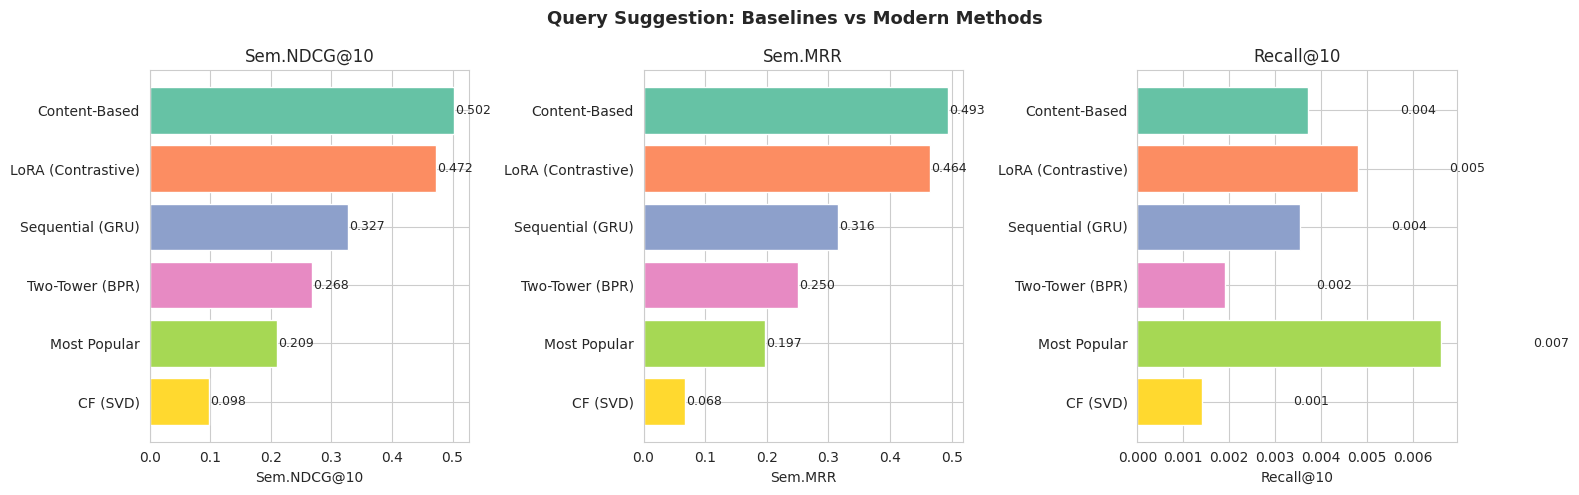

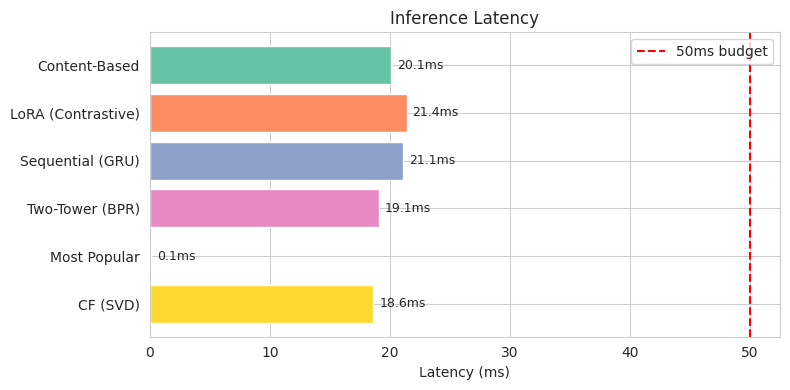

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = sns.color_palette('Set2', len(summary))
metrics = [c for c in summary.columns if 'Latency' not in c]
for ax, metric in zip(axes, metrics):
    vals = summary[metric].values
    bars = ax.barh(range(len(summary)), vals, color=colors)
    ax.set_yticks(range(len(summary))); ax.set_yticklabels(summary.index)
    ax.set_xlabel(metric); ax.set_title(metric); ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2.,
                f'{val:.3f}', ha='left', va='center', fontsize=9)
plt.suptitle('Query Suggestion: Baselines vs Modern Methods', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

if 'Latency(ms)' in summary.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    lat = summary['Latency(ms)']
    ax.barh(range(len(lat)), lat.values, color=colors)
    ax.set_yticks(range(len(lat))); ax.set_yticklabels(lat.index)
    ax.set_xlabel('Latency (ms)'); ax.set_title('Inference Latency'); ax.invert_yaxis()
    ax.axvline(x=50, color='red', linestyle='--', label='50ms budget')
    ax.legend()
    for i, v in enumerate(lat.values):
        ax.text(v+0.5, i, f'{v:.1f}ms', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

### Why do simpler methods win? (Discussion)

The results above may seem counterintuitive — shouldn't fancy neural models beat a simple average? Two key things are happening:

**1. Content-Based wins because the pretrained embeddings are already excellent.**

`all-MiniLM-L6-v2` was trained on hundreds of millions of text pairs. It already "knows" that queries about cooking are similar to each other. The Content-Based method simply leverages this by averaging the user's past query embeddings into a profile — no training needed. The Two-Tower and GRU models, on the other hand, try to *learn a transformation* of these embeddings from our relatively small training set (~12K users). With limited data, they can easily learn noise instead of signal, or even destroy the useful structure already present in the pretrained space.

**Lesson:** Don't train when you can reuse. A good pretrained representation + simple aggregation often beats a trained model with insufficient data.

**2. CF (SVD) is terrible because the interaction matrix is astronomically sparse.**

There are 429K unique query strings but only ~100 interactions per user on average. The user-query matrix is >99.99% zeros. SVD has almost nothing to work with. Worse, CF treats each query as an opaque ID — it cannot know that "cat food" and "kitten food" are related. Text-based methods generalize across semantically similar queries; CF cannot.

**Lesson:** Collaborative filtering needs dense interactions. For long-tail items (or queries), content-based methods dominate.

**Bonus: Naive Python vs vectorized code**

Notice the speed comparison earlier in the popularity baseline cell. The naive `for q in popular_queries` loop over 400K+ strings was orders of magnitude slower than the numpy-masked version — even though both implement the exact same "algorithm." In production systems, this kind of optimization matters as much as the ML model choice.

## 12. Qualitative Analysis

In [25]:
for uid in test_users[:3]:
    print(f'\n{"="*70}')
    print(f'USER {uid}')
    print(f'History (last 5): {user_history[uid][-5:]}')
    print(f'Ground truth:     {test_ground_truth[uid][:3]}')
    print(f'{"-"*70}')
    for name, fn in [('Popular', recommend_popular), ('Content', recommend_content_based),
                     ('CF', recommend_cf), ('Two-Tower', recommend_two_tower),
                     ('GRU', recommend_gru), ('LoRA', recommend_lora)]:
        print(f'  {name:12s}: {fn(uid, 3)}')


USER 1035
History (last 5): ['google', 'diaryland', 'google', 'rectal cancer', 'www.dehanas realestate service']
Ground truth:     ['google', 'google', 'people search']
----------------------------------------------------------------------
  Popular     : ['ebay', 'myspace', 'yahoo.com']
  Content     : ["google'", 'google.', 'googles']
  CF          : ['hi5', 'sbc yahoo', 'jennie finch']
  Two-Tower   : ['craigslist.', 'my ebay', 'google.']
  GRU         : ['google.', 'mapquest', "google'"]
  LoRA        : ['google.', 'babeland', 'quoteland']

USER 1338
History (last 5): ['thesabre', 'thesabre', 'thesabre', 'thesabre', 'thesabre']
Ground truth:     ['thesabre', 'pilotonline.com', 'thesabre']
----------------------------------------------------------------------
  Popular     : ['google', 'yahoo', 'ebay']
  Content     : ['gamebrew', 'fromsadtoraw', 'cascada']
  CF          : ['iranian singles connection', 'voyeur', 'usbank']
  Two-Tower   : ['viva el birdos', 'conquer', 'shemalecharm

## 13. Two-Stage Architecture: Retrieval + LTR Ranking

These models are **candidate generators** (stage 1). Combined with **LTR ranking** (stage 2, see [first tutorial](ltr_tutorial.ipynb)):

```
Stage 1: Retrieval (this tutorial)          Stage 2: Ranking (LTR tutorial)
  Two-Tower / GRU / CF / LoRA        →        LambdaMART with features:
  → top 100 candidates                         score_from_each_retriever,
                                                text_sim, popularity, ...
                                              → optimizes NDCG directly
```

This is the industry standard (Google, Meta, Recombee, ...).

## Key Takeaways

| Method | Type | Strengths | Weaknesses |
|--------|------|-----------|------------|
| Most Popular | Baseline | Simple, fast | Not personalized |
| Content-Based | Baseline | Handles cold-start | Ignores collaborative signal |
| CF (SVD) | Baseline | Co-search patterns | Cold-start, no text |
| Two-Tower (BPR) | Modern | Scalable retrieval | Averages history |
| Sequential (GRU) | Modern | Temporal patterns | Complex, needs data |
| LoRA (Contrastive) | Modern | Lightweight fine-tuning | Must recompute embeddings after retrain |

1. **Two-stage** (retrieval + ranking) is the industry standard
2. **Embeddings** bridge content and collaborative signals
3. **LoRA** enables domain adaptation without full model retraining
4. **Latency matters**: the best model is useless if too slow for production
5. **Semantic eval** is essential for text tasks — exact match underestimates quality
6. **Simpler models sometimes win**: a well-tuned baseline can beat a complex model

---

**Next:** Open [assignment.ipynb](assignment.ipynb) for the independent student exercise — beat the baselines with your own method!